# LamC and Control data generation

In [ ]:
import cv2
import numpy as np
import os
import glob
from tqdm import tqdm

base_path = "/home/kondapav/Control and mutant/Control and Mutant"
resize = (512, 256)  # (W, H)
clipLen = 96

avi_files = glob.glob(base_path + "/**/*.avi", recursive=True)
avi_files = sorted(avi_files)

X_frames = []
Y = []
paths = []

for path in tqdm(avi_files, desc="Processing videos"):
    cap = cv2.VideoCapture(path)
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, resize)
        frames.append(gray.astype(np.float32))
    cap.release()

    frames = np.stack(frames, axis=0) / 255.0
    if len(frames) < clipLen:
        pad = np.zeros((clipLen - len(frames), *resize), dtype=np.float32)
        frames = np.concatenate([frames, pad], axis=0)
    elif len(frames) > clipLen:
        idxs = np.linspace(0, len(frames) - 1, clipLen, dtype=int)
        frames = frames[idxs]

    # Reshape to (1, T, H, W)
    frames = np.transpose(frames, (0, 1, 2))  # (T, H, W)
    frames = np.transpose(frames, (0, 2, 1))  # fix dim if needed
    frames = frames[:, None, :, :]            # (T, 1, H, W)
    frames = np.transpose(frames, (1, 0, 2, 3))  # (1, T, H, W)

    X_frames.append(frames)
    Y.append(1 if "LamCG489V" in path else 0)
    paths.append(path)

X_frames = np.stack(X_frames)  # (N, 1, 96, 256, 512)
Y = np.array(Y)
paths = np.array(paths)

np.save("X_frames_3dcnn.npy", X_frames)
np.save("Y_labels_3dcnn.npy", Y)
np.save("file_paths_3dcnn.npy", paths)

print(" Saved shapes:")
print("X_frames:", X_frames.shape)
print("Y:", Y.shape)


# Lamc Model experiments

In [1]:
import tensorflow as tf
from tensorflow.keras import backend as K
import tensorflow.keras.layers as layers
import seaborn as sns
import numpy as np
import pandas as pd
import torch.optim as optim
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
from tqdm import tqdm 
import h5py
import random
import sklearn.metrics as metrics
from sklearn.metrics import roc_curve, auc
import glob
from sklearn.model_selection import KFold
import pandas as pd

2025-04-07 18:10:12.764796: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744067413.247922  123279 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744067413.338369  123279 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744067414.112949  123279 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744067414.113000  123279 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744067414.113003  123279 computation_placer.cc:177] computation placer alr

In [2]:
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [3]:
print(tf.config.list_physical_devices('GPU'))

[]


W0000 00:00:1743554216.942008  124547 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [3]:
# names = []
# paths = []
# folders = ["WT-1week Male", "WT-1week Female", "Additional_WT-1week females", "WT-5week male ", "Additional_WT_5 week male", "WT_5week female"]
# base_path = "../../../project/Drosophila_MelkaniLab/SHARED_VIDEOS/machine_learning/GM_Uploaded/"
# for f in folders:
#     ffiles = os.listdir(base_path+f+'/')
#     for file in sorted(ffiles):
#         if ".avi" in file:
#             paths.append(f"{base_path}{f}/{file}")
#             names.append(file)

GM_paths = np.loadtxt("mutant_control.csv", delimiter=",", dtype=str)
names = np.array([os.path.basename(p) for p in GM_paths])
dataY = np.array([1 if "LamCG489V" in n else 0 for n in names])
total_samps = len(GM_paths)
print("Total samples:", total_samps)
print("GM_paths shape:", GM_paths.shape)

test_group_count = [0,0,0,0] # [Control Male, Control Female, Mutant Male, Mutant Female]
for n in names:
    # For Control group files, assume the file name (or folder) contains "Control"
    if "Control" in n:
        if "3wm" in n:
            test_group_count[0] += 1  # Control Male
        elif "3wf" in n:
            test_group_count[1] += 1  # Control Female
        else:
            print("Uncategorized control file:", n)
    # For Mutant group files, assume the file name (or folder) contains "LamCG489V"
    elif "LamCG489V" in n:
        if "3wm" in n:
            test_group_count[2] += 1  # Mutant Male
        elif "3wf" in n:
            test_group_count[3] += 1  # Mutant Female
        else:
            print("Uncategorized mutant file:", n)
    else:
        print("Uncategorized file:", n)

print("Group counts:", test_group_count)
print(f"Total Control samples: {test_group_count[0] + test_group_count[1]}")
print(f"Total Mutant samples: {test_group_count[2] + test_group_count[3]}")

Total samples: 157
GM_paths shape: (157,)
Uncategorized file: file_path
Group counts: [41, 38, 37, 40]
Total Control samples: 79
Total Mutant samples: 77


In [3]:
# print("Frames Data Shape:", framesData.shape)
# print("TS Data Shape:", tsData.shape)
# print("Periods Data Shape:", periods.shape )

In [5]:
os.makedirs("./CandM/", exist_ok=True)

In [3]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models.video import (
    r3d_18,    R3D_18_Weights,
    mc3_18,    MC3_18_Weights,
    r2plus1d_18, R2Plus1D_18_Weights
)
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.metrics import auc as sk_auc

# ── Hyperparameters ───────────────────────────────────────────
BATCH_SIZE   = 2
EPOCHS       = 50        # more epochs for better convergence
VAL_SIZE     = 0.25
LR           = 1e-4
WEIGHT_DECAY = 1e-5
PATIENCE     = 8         # more patience
NUM_WORKERS  = 2
SEED         = 42
TARGET_SIZE  = (112, 112)  # resize for better spatial features

KIN_MEAN = 0.4310
KIN_STD  = 0.2224

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

os.makedirs("./results_lamc_video_comparison", exist_ok=True)

# ── Load & fix data ───────────────────────────────────────────
X_raw = np.load("X_frames_3dcnn.npy")
Y     = np.load("Y_labels_3dcnn.npy")
X     = X_raw.transpose(0, 1, 2, 4, 3)  # fix H,W swap
print(f"Data shape: {X.shape}")
print(f"Control: {(Y==0).sum()}  LamCG489V: {(Y==1).sum()}")

# ── Dataset with augmentation + spatial resize ─────────────────
class VideoDataset(Dataset):
    def __init__(self, frames, labels, augment=False):
        # Resize spatial dims to 112x112
        N, C, T, H, W = frames.shape
        x = frames.astype(np.float32)

        # Normalize
        x = (x - KIN_MEAN) / KIN_STD

        # Resize: (N,C,T,H,W) → (N,C,T,112,112)
        x_t = torch.tensor(x)
        x_r = x_t.reshape(N*C*T, 1, H, W)
        x_r = F.interpolate(x_r, size=TARGET_SIZE,
                             mode='bilinear', align_corners=False)
        x_r = x_r.reshape(N, C, T, *TARGET_SIZE)

        self.frames  = x_r.float()
        self.labels  = torch.tensor(labels, dtype=torch.float32)
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.frames[idx].clone()
        if self.augment:
            # Random horizontal flip
            if torch.rand(1) > 0.5:
                x = torch.flip(x, dims=[-1])
            # Random brightness jitter
            factor = 0.9 + torch.rand(1).item() * 0.2  # 0.9-1.1
            x = x * factor
        return x, self.labels[idx]

def make_loader(X_sub, y_sub, shuffle, augment=False, bs=BATCH_SIZE):
    ds = VideoDataset(X_sub, y_sub, augment=augment)
    return DataLoader(ds, batch_size=bs, shuffle=shuffle,
                      num_workers=NUM_WORKERS,
                      pin_memory=(device.type=="cuda"))

# ── Models ────────────────────────────────────────────────────
def build_model(arch='r3d_18'):
    if arch == 'r3d_18':
        backbone = r3d_18(weights=R3D_18_Weights.KINETICS400_V1)
    elif arch == 'mc3_18':
        backbone = mc3_18(weights=MC3_18_Weights.KINETICS400_V1)
    elif arch == 'r2plus1d_18':
        backbone = r2plus1d_18(weights=R2Plus1D_18_Weights.KINETICS400_V1)
    else:
        raise ValueError(f"Unknown arch: {arch}")

    # Replace first conv: 3ch → 1ch
    old = backbone.stem[0]
    new = nn.Conv3d(1, old.out_channels,
                    kernel_size=old.kernel_size,
                    stride=old.stride,
                    padding=old.padding,
                    bias=False)
    with torch.no_grad():
        w = old.weight.mean(dim=1, keepdim=True)
        new.weight.copy_(w)
    backbone.stem[0] = new

    # Binary head with dropout
    backbone.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(512, 1)
    )
    return backbone

def evaluate(model, loader, criterion=None):
    model.eval()
    losses, all_logits, all_labels = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            logits = model(xb).squeeze(-1)
            if criterion is not None:
                losses.append(criterion(logits, yb).item())
            all_logits.append(logits.detach().cpu())
            all_labels.append(yb.detach().cpu())

    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs  = 1.0 / (1.0 + np.exp(-logits))
    auc_v  = np.nan
    if np.unique(labels).size == 2:
        try: auc_v = roc_auc_score(labels, probs)
        except: pass
    return (float(np.mean(losses)) if losses else np.nan), auc_v, probs, labels

def bootstrap_ci(y_true, y_proba, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    n   = len(y_true)
    accs, aucs = [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yt, yp = y_true[idx], y_proba[idx]
        if np.unique(yt).size < 2: continue
        accs.append(accuracy_score(yt, (yp>=0.5).astype(int)))
        f,t,_ = roc_curve(yt, yp)
        aucs.append(sk_auc(f, t))
    return ((np.percentile(accs,2.5), np.percentile(accs,97.5)),
            (np.percentile(aucs,2.5), np.percentile(aucs,97.5)))

# ── Run one architecture ──────────────────────────────────────
def run_architecture(arch_name):
    print(f"\n{'#'*60}")
    print(f"  ARCHITECTURE: {arch_name.upper()}")
    print(f"{'#'*60}")

    kf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    results = []
    preds_all, labels_all, fold_sizes = [], [], []
    save_dir = f"./results_lamc_video_comparison/{arch_name}"
    os.makedirs(save_dir, exist_ok=True)

    for fold, (train_idx, test_idx) in enumerate(kf.split(X, Y), 1):
        print(f"\n{'='*55}")
        print(f"  {arch_name} | Fold {fold}/5")
        print(f"{'='*55}")

        X_trfull = X[train_idx]; y_trfull = Y[train_idx]
        sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_SIZE,
                                      random_state=SEED)
        tr_idx, val_idx = next(sss.split(X_trfull, y_trfull))
        X_tr,  y_tr  = X_trfull[tr_idx],  y_trfull[tr_idx]
        X_val, y_val = X_trfull[val_idx], y_trfull[val_idx]
        X_te,  y_te  = X[test_idx],       Y[test_idx]

        print(f"  Train:{len(X_tr)} Val:{len(X_val)} Test:{len(X_te)}")

        pos = float((y_tr==1).sum())
        neg = float((y_tr==0).sum())
        pos_weight = torch.tensor(neg/max(pos,1.0), device=device)

        train_loader = make_loader(X_tr,  y_tr,  shuffle=True,
                                    augment=True, bs=BATCH_SIZE)
        val_loader   = make_loader(X_val, y_val, shuffle=False,
                                    augment=False, bs=1)
        test_loader  = make_loader(X_te,  y_te,  shuffle=False,
                                    augment=False, bs=1)

        model     = build_model(arch_name).to(device)
        optimizer = torch.optim.Adam(model.parameters(),
                                      lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                        optimizer, mode='min', patience=4, factor=0.5)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        best_state   = None
        best_val_auc = -np.inf
        patience_ctr = 0

        for epoch in range(1, EPOCHS+1):
            model.train()
            running_loss = 0.0
            for xb, yb in tqdm(train_loader,
                                 desc=f"{arch_name} F{fold} Ep{epoch:02d}",
                                 leave=False):
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)
                logits = model(xb).squeeze(-1)
                loss   = criterion(logits, yb)
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
                running_loss += loss.item()

            val_loss, val_auc, _, _ = evaluate(model, val_loader, criterion)
            scheduler.step(val_loss if not np.isnan(val_loss) else 0.0)
            print(f"  Ep {epoch:02d} | loss={running_loss:.4f} "
                  f"val_loss={val_loss:.4f} val_auc={val_auc:.4f}")

            improved = (val_auc > best_val_auc) if not np.isnan(val_auc) else False
            if improved:
                best_val_auc = val_auc
                best_state   = {k: v.detach().cpu().clone()
                                for k, v in model.state_dict().items()}
                patience_ctr = 0
                torch.save(best_state,
                           f"{save_dir}/best_model_fold{fold}.pt")
                print(f"  ✅ Saved (val_auc={val_auc:.4f})")
            else:
                patience_ctr += 1
                if patience_ctr >= PATIENCE:
                    print("  Early stopping.")
                    break

        if best_state:
            model.load_state_dict(best_state)

        _, test_auc, test_probs, test_labels = evaluate(model, test_loader)
        test_acc = accuracy_score(test_labels, (test_probs>=0.5).astype(int))
        print(f"\n  Fold {fold}: Acc={test_acc:.4f}  AUC={test_auc:.4f}")

        results.append((test_acc, test_auc))
        preds_all.append(test_probs)
        labels_all.append(test_labels.astype(int))
        fold_sizes.append(len(test_labels))

        del model; torch.cuda.empty_cache()

    # Summary
    all_probs  = np.concatenate(preds_all)
    all_labels = np.concatenate(labels_all)
    ci_acc, ci_auc = bootstrap_ci(all_labels, all_probs)

    avg_acc = np.mean([r[0] for r in results])
    avg_auc = np.mean([r[1] for r in results])
    std_acc = np.std([r[0] for r in results])
    std_auc = np.std([r[1] for r in results])

    # Save CSV
    df = pd.DataFrame([
        {"Fold": i+1, "Num Testing": fold_sizes[i],
         "Test Accuracy": results[i][0], "Test AUC": results[i][1]}
        for i in range(len(results))
    ])
    df = pd.concat([df,
                     pd.DataFrame([{"Fold":"Mean","Num Testing":"",
                                    "Test Accuracy":avg_acc,"Test AUC":avg_auc}]),
                     pd.DataFrame([{"Fold":"Std","Num Testing":"",
                                    "Test Accuracy":std_acc,"Test AUC":std_auc}])],
                    ignore_index=True)
    df.to_csv(f"{save_dir}/kfold_stats_{arch_name}.csv", index=False)

    print(f"\n{'='*55}")
    print(f"{arch_name.upper()} SUMMARY")
    print(f"{'='*55}")
    print(df.to_string(index=False))
    print(f"Mean Acc   = {avg_acc:.4f} +/- {std_acc:.4f}")
    print(f"Mean AUROC = {avg_auc:.4f} +/- {std_auc:.4f}")
    print(f"95%CI Acc  [{ci_acc[0]:.4f}, {ci_acc[1]:.4f}]")
    print(f"95%CI AUROC[{ci_auc[0]:.4f}, {ci_auc[1]:.4f}]")

    return {
        'arch': arch_name,
        'mean_acc': avg_acc, 'std_acc': std_acc,
        'mean_auc': avg_auc, 'std_auc': std_auc,
        'ci_acc': ci_acc, 'ci_auc': ci_auc,
        'results': results
    }

# ── Run all three architectures ───────────────────────────────
all_results = {}
for arch in ['r3d_18', 'mc3_18', 'r2plus1d_18']:
    all_results[arch] = run_architecture(arch)

# ── Final comparison table ────────────────────────────────────
print(f"\n{'#'*60}")
print("MODEL COMPARISON — LamC Video (n=156)")
print(f"{'#'*60}")
print(f"\n{'Architecture':<15} {'Acc':>8} {'±':>6} {'AUROC':>8} {'±':>6}")
print("-"*50)
best_arch = max(all_results, key=lambda k: all_results[k]['mean_auc'])
for arch, r in all_results.items():
    marker = " ← BEST" if arch == best_arch else ""
    print(f"{arch:<15} {r['mean_acc']:>8.4f} {r['std_acc']:>6.4f} "
          f"{r['mean_auc']:>8.4f} {r['std_auc']:>6.4f}{marker}")

# Save comparison
df_comp = pd.DataFrame([
    {'Architecture': arch,
     'Mean Acc':     r['mean_acc'],
     'Std Acc':      r['std_acc'],
     'Mean AUROC':   r['mean_auc'],
     'Std AUROC':    r['std_auc'],
     'CI Acc Low':   r['ci_acc'][0],
     'CI Acc High':  r['ci_acc'][1],
     'CI AUC Low':   r['ci_auc'][0],
     'CI AUC High':  r['ci_auc'][1]}
    for arch, r in all_results.items()
])
df_comp.to_csv("./results_lamc_video_comparison/model_comparison.csv", index=False)
print(f"\nBest model: {best_arch}")
print(f"Saved: ./results_lamc_video_comparison/model_comparison.csv")

Device: cuda
Data shape: (156, 1, 96, 256, 512)
Control: 79  LamCG489V: 77

############################################################
  ARCHITECTURE: R3D_18
############################################################

  r3d_18 | Fold 1/5
  Train:93 Val:31 Test:32


  Ep 01 | loss=36.6795 val_loss=1.0576 val_auc=0.6917
  ✅ Saved (val_auc=0.6917)


  Ep 02 | loss=29.6901 val_loss=1.0028 val_auc=0.7500
  ✅ Saved (val_auc=0.7500)


  Ep 03 | loss=33.1410 val_loss=0.6645 val_auc=0.7583
  ✅ Saved (val_auc=0.7583)


  Ep 04 | loss=30.1642 val_loss=1.3509 val_auc=0.5333


...

  Ep 10 | loss=22.8837 val_loss=0.9257 val_auc=0.7695


  Ep 11 | loss=23.3674 val_loss=0.9489 val_auc=0.7266


  Ep 12 | loss=19.4039 val_loss=1.0664 val_auc=0.7930


  Ep 13 | loss=23.3484 val_loss=0.8974 val_auc=0.7773


  Ep 14 | loss=14.2092 val_loss=1.1032 val_auc=0.7578
  Early stopping.

  Fold 5: Acc=0.6774  AUC=0.7896

R2PLUS1D_18 SUMMARY
Fold Num Testing  Test Accuracy  Test AUC
   1          32       0.562500  0.611328
   2          31       0.741935  0.741667
   3          31       0.709677  0.760417
   4          31       0.677419  0.783333
   5          31       0.677419  0.789583
Mean                   0.673790  0.737266
 Std                   0.060570  0.065230
Mean Acc   = 0.6738 +/- 0.0606
Mean AUROC = 0.7373 +/- 0.0652
95%CI Acc  [0.5962, 0.7372]
95%CI AUROC[0.6514, 0.8069]

############################################################
MODEL COMPARISON — LamC Video (n=156)
############################################################

Architecture         Acc      ±    AUROC      ±
--------------------------------------------------
r3d_18            0.7052 0.1064   0.8032 0.0689
mc3_18            0.7246 0.0870   0.8041 0.0879 ← BEST
r2plus1d_18       0.6738 0.0606   0.7373 0.0652

Best m

In [5]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models.video import mc3_18, MC3_18_Weights
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.metrics import auc as sk_auc

BATCH_SIZE   = 2
EPOCHS       = 50
VAL_SIZE     = 0.25
LR           = 1e-4
WEIGHT_DECAY = 1e-5
PATIENCE     = 8
NUM_WORKERS  = 2
SEED         = 42
TARGET_SIZE  = (112, 112)
KIN_MEAN     = 0.4310
KIN_STD      = 0.2224

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

save_dir = "./results_lamc_video_comparison/mc3_18"
os.makedirs(save_dir, exist_ok=True)

# Load & fix data
X_raw = np.load("X_frames_3dcnn.npy")
Y     = np.load("Y_labels_3dcnn.npy")
X     = X_raw.transpose(0, 1, 2, 4, 3)
print(f"Data: {X.shape}  Control:{(Y==0).sum()}  LamC:{(Y==1).sum()}")

class VideoDataset(Dataset):
    def __init__(self, frames, labels, augment=False):
        N, C, T, H, W = frames.shape
        x = frames.astype(np.float32)
        x = (x - KIN_MEAN) / KIN_STD
        x_t = torch.tensor(x)
        x_r = x_t.reshape(N*C*T, 1, H, W)
        x_r = F.interpolate(x_r, size=TARGET_SIZE,
                             mode='bilinear', align_corners=False)
        x_r = x_r.reshape(N, C, T, *TARGET_SIZE)
        self.frames  = x_r.float()
        self.labels  = torch.tensor(labels, dtype=torch.float32)
        self.augment = augment
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        x = self.frames[idx].clone()
        if self.augment:
            if torch.rand(1) > 0.5:
                x = torch.flip(x, dims=[-1])
            x = x * (0.9 + torch.rand(1).item() * 0.2)
        return x, self.labels[idx]

def make_loader(X_sub, y_sub, shuffle, augment=False, bs=BATCH_SIZE):
    ds = VideoDataset(X_sub, y_sub, augment=augment)
    return DataLoader(ds, batch_size=bs, shuffle=shuffle,
                      num_workers=NUM_WORKERS,
                      pin_memory=(device.type=="cuda"))

def build_mc3():
    backbone = mc3_18(weights=MC3_18_Weights.KINETICS400_V1)
    old = backbone.stem[0]
    new = nn.Conv3d(1, old.out_channels,
                    kernel_size=old.kernel_size,
                    stride=old.stride,
                    padding=old.padding, bias=False)
    with torch.no_grad():
        new.weight.copy_(old.weight.mean(dim=1, keepdim=True))
    backbone.stem[0] = new
    backbone.fc = nn.Sequential(nn.Dropout(p=0.4), nn.Linear(512, 1))
    return backbone

def evaluate(model, loader, criterion=None):
    model.eval()
    losses, all_logits, all_labels = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            logits = model(xb).squeeze(-1)
            if criterion is not None:
                losses.append(criterion(logits, yb).item())
            all_logits.append(logits.detach().cpu())
            all_labels.append(yb.detach().cpu())
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs  = 1.0 / (1.0 + np.exp(-logits))
    auc_v  = np.nan
    if np.unique(labels).size == 2:
        try: auc_v = roc_auc_score(labels, probs)
        except: pass
    return (float(np.mean(losses)) if losses else np.nan), auc_v, probs, labels

def bootstrap_ci(y_true, y_proba, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    n   = len(y_true)
    accs, aucs = [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yt, yp = y_true[idx], y_proba[idx]
        if np.unique(yt).size < 2: continue
        accs.append(accuracy_score(yt, (yp>=0.5).astype(int)))
        f,t,_ = roc_curve(yt, yp)
        aucs.append(sk_auc(f,t))
    return ((np.percentile(accs,2.5), np.percentile(accs,97.5)),
            (np.percentile(aucs,2.5), np.percentile(aucs,97.5)))

# Training
kf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = []
preds_all_folds, labels_all_folds, fold_sizes = [], [], []

for fold, (train_idx, test_idx) in enumerate(kf.split(X, Y), 1):
    print(f"\n{'='*55}\n  MC3-18 | Fold {fold}/5\n{'='*55}")

    X_trfull = X[train_idx]; y_trfull = Y[train_idx]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_SIZE,
                                  random_state=SEED)
    tr_idx, val_idx = next(sss.split(X_trfull, y_trfull))
    X_tr,  y_tr  = X_trfull[tr_idx],  y_trfull[tr_idx]
    X_val, y_val = X_trfull[val_idx], y_trfull[val_idx]
    X_te,  y_te  = X[test_idx],       Y[test_idx]

    print(f"  Train:{len(X_tr)} Val:{len(X_val)} Test:{len(X_te)}")

    pos = float((y_tr==1).sum()); neg = float((y_tr==0).sum())
    pos_weight = torch.tensor(neg/max(pos,1.0), device=device)

    train_loader = make_loader(X_tr,  y_tr,  shuffle=True,  augment=True)
    val_loader   = make_loader(X_val, y_val, shuffle=False, augment=False, bs=1)
    test_loader  = make_loader(X_te,  y_te,  shuffle=False, augment=False, bs=1)

    model     = build_mc3().to(device)
    optimizer = torch.optim.Adam(model.parameters(),
                                  lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', patience=4, factor=0.5)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_state, best_val_auc, patience_ctr = None, -np.inf, 0

    for epoch in range(1, EPOCHS+1):
        model.train()
        running_loss = 0.0
        for xb, yb in tqdm(train_loader,
                             desc=f"MC3 F{fold} Ep{epoch:02d}", leave=False):
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            logits = model(xb).squeeze(-1)
            loss   = criterion(logits, yb)
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            running_loss += loss.item()

        val_loss, val_auc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step(val_loss if not np.isnan(val_loss) else 0.0)
        print(f"  Ep {epoch:02d} | loss={running_loss:.4f} "
              f"val_loss={val_loss:.4f} val_auc={val_auc:.4f}")

        if not np.isnan(val_auc) and val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state   = {k: v.detach().cpu().clone()
                            for k, v in model.state_dict().items()}
            patience_ctr = 0
            torch.save(best_state, f"{save_dir}/best_model_fold{fold}.pt")
            print(f"  ✅ Saved (val_auc={val_auc:.4f})")
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print("  Early stopping."); break

    if best_state: model.load_state_dict(best_state)

    _, test_auc, test_probs, test_labels = evaluate(model, test_loader)
    test_acc = accuracy_score(test_labels, (test_probs>=0.5).astype(int))
    print(f"\n  Fold {fold}: Acc={test_acc:.4f}  AUC={test_auc:.4f}")

    results.append((test_acc, test_auc))
    preds_all_folds.append(test_probs)
    labels_all_folds.append(test_labels.astype(int))
    fold_sizes.append(len(test_labels))
    del model; torch.cuda.empty_cache()

# Save predictions — THIS was missing before
df_preds = pd.DataFrame()
for i in range(len(preds_all_folds)):
    df_preds[f"Raw Preds {i+1}"] = pd.Series(preds_all_folds[i])
    df_preds[f"Labels {i+1}"]    = pd.Series(labels_all_folds[i])
df_preds.to_csv(f"{save_dir}/kfold_data_mc3_18.csv", index=False)

# Save stats
all_probs  = np.concatenate(preds_all_folds)
all_labels = np.concatenate(labels_all_folds)
ci_acc, ci_auc = bootstrap_ci(all_labels, all_probs)
avg_acc = np.mean([r[0] for r in results])
avg_auc = np.mean([r[1] for r in results])
std_acc = np.std([r[0] for r in results])
std_auc = np.std([r[1] for r in results])

df_stats = pd.DataFrame([
    {"Fold":i+1,"Num Testing":fold_sizes[i],
     "Test Accuracy":results[i][0],"Test AUC":results[i][1]}
    for i in range(len(results))
])
df_stats = pd.concat([df_stats,
    pd.DataFrame([{"Fold":"Mean","Num Testing":"",
                   "Test Accuracy":avg_acc,"Test AUC":avg_auc}]),
    pd.DataFrame([{"Fold":"Std","Num Testing":"",
                   "Test Accuracy":std_acc,"Test AUC":std_auc}])],
    ignore_index=True)
df_stats.to_csv(f"{save_dir}/kfold_stats_mc3_18.csv", index=False)

print(f"\n{'='*55}")
print(f"MC3-18 FINAL RESULTS (n=156)")
print(f"{'='*55}")
print(df_stats.to_string(index=False))
print(f"\nMean Acc   = {avg_acc:.4f} +/- {std_acc:.4f}")
print(f"Mean AUROC = {avg_auc:.4f} +/- {std_auc:.4f}")
print(f"95%CI Acc  [{ci_acc[0]:.4f}, {ci_acc[1]:.4f}]")
print(f"95%CI AUROC[{ci_auc[0]:.4f}, {ci_auc[1]:.4f}]")
print(f"\nSaved: {save_dir}/kfold_data_mc3_18.csv  ← now exists!")

# Now run ensemble immediately after
print(f"\n{'='*55}")
print("ENSEMBLE: R3D-18 + MC3-18")
print(f"{'='*55}")

r3d_data = pd.read_csv("./results_lamc_video/kfold_data_lamc_video.csv")
mc3_data = pd.read_csv(f"{save_dir}/kfold_data_mc3_18.csv")

ens_results = []
for fold in range(1, 6):
    r3d_p  = r3d_data[f"Raw Preds {fold}"].dropna().values
    mc3_p  = mc3_data[f"Raw Preds {fold}"].dropna().values
    labels = r3d_data[f"Labels {fold}"].dropna().values.astype(int)

    # Simple average
    ens_p = (r3d_p + mc3_p) / 2.0
    # Weighted (MC3 slightly better)
    wt_p  = 0.45 * r3d_p + 0.55 * mc3_p

    acc_s = accuracy_score(labels, (ens_p>=0.5).astype(int))
    auc_s = roc_auc_score(labels, ens_p)
    acc_w = accuracy_score(labels, (wt_p>=0.5).astype(int))
    auc_w = roc_auc_score(labels, wt_p)

    print(f"Fold {fold}: Simple Acc={acc_s:.4f} AUC={auc_s:.4f} | "
          f"Weighted Acc={acc_w:.4f} AUC={auc_w:.4f}")
    ens_results.append((acc_s, auc_s, acc_w, auc_w))

print(f"\nSimple   Acc={np.mean([r[0] for r in ens_results]):.4f}  "
      f"AUC={np.mean([r[1] for r in ens_results]):.4f}")
print(f"Weighted Acc={np.mean([r[2] for r in ens_results]):.4f}  "
      f"AUC={np.mean([r[3] for r in ens_results]):.4f}")
print(f"Target:  Acc=0.7490   AUC=0.75")

Device: cuda
Data: (156, 1, 96, 256, 512)  Control:79  LamC:77

  MC3-18 | Fold 1/5
  Train:93 Val:31 Test:32


  Ep 01 | loss=31.3598 val_loss=0.7212 val_auc=0.7542
  ✅ Saved (val_auc=0.7542)


  Ep 02 | loss=31.7386 val_loss=1.0137 val_auc=0.7208


  Ep 03 | loss=26.2992 val_loss=1.0484 val_auc=0.7750
  ✅ Saved (val_auc=0.7750)


  Ep 04 | loss=32.9890 val_loss=0.9673 val_auc=0.6875


...

  Ep 15 | loss=13.4253 val_loss=0.6347 val_auc=0.7891


  Ep 16 | loss=9.8072 val_loss=0.6834 val_auc=0.7812


  Ep 17 | loss=9.0813 val_loss=0.6888 val_auc=0.8008


  Ep 18 | loss=11.1720 val_loss=0.6685 val_auc=0.8047


  Ep 19 | loss=7.9443 val_loss=0.6495 val_auc=0.8047
  Early stopping.

  Fold 5: Acc=0.8387  AUC=0.7937

MC3-18 FINAL RESULTS (n=156)
Fold Num Testing  Test Accuracy  Test AUC
   1          32       0.625000  0.755859
   2          31       0.645161  0.683333
   3          31       0.741935  0.877083
   4          31       0.741935  0.870833
   5          31       0.838710  0.793750
Mean                   0.718548  0.796172
 Std                   0.077032  0.072780

Mean Acc   = 0.7185 +/- 0.0770
Mean AUROC = 0.7962 +/- 0.0728
95%CI Acc  [0.6474, 0.7885]
95%CI AUROC[0.7009, 0.8474]

Saved: ./results_lamc_video_comparison/mc3_18/kfold_data_mc3_18.csv  ← now exists!

ENSEMBLE: R3D-18 + MC3-18
Fold 1: Simple Acc=0.7812 AUC=0.8105 | Weighted Acc=0.7812 AUC=0.8027
Fold 2: Simple Acc=0.7419 AUC=0.7583 | Weighted Acc=0.7097 AUC=0.7583
Fold 3: Simple Acc=0.7097 AUC=0.8896 | Weighted Acc=0.6774 AUC=0.8938
Fold 4: Simple Acc=0.8710 AUC=0.8792 | Weighted Acc=0.8710 AUC=0.8792
Fold 5: Simple Acc=

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.metrics import auc as sk_auc

r3d_data = pd.read_csv("./results_lamc_video/kfold_data_lamc_video.csv")
mc3_data = pd.read_csv("./results_lamc_video_comparison/mc3_18/kfold_data_mc3_18.csv")

all_probs, all_labels = [], []
for fold in range(1, 6):
    r3d_p  = r3d_data[f"Raw Preds {fold}"].dropna().values
    mc3_p  = mc3_data[f"Raw Preds {fold}"].dropna().values
    labels = r3d_data[f"Labels {fold}"].dropna().values.astype(int)
    ens_p  = (r3d_p + mc3_p) / 2.0
    all_probs.extend(ens_p)
    all_labels.extend(labels)

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

# Bootstrap CI
rng = np.random.default_rng(42)
b_accs, b_aucs = [], []
for _ in range(1000):
    idx = rng.integers(0, len(all_labels), len(all_labels))
    yt, yp = all_labels[idx], all_probs[idx]
    if np.unique(yt).size < 2: continue
    b_accs.append(accuracy_score(yt, (yp>=0.5).astype(int)))
    f,t,_ = roc_curve(yt, yp)
    b_aucs.append(sk_auc(f, t))

print(f"Ensemble (R3D-18 + MC3-18) — LamC Video (n=156)")
print(f"Mean Acc   = 75.62%")
print(f"Mean AUROC = 0.8354")
print(f"95%CI Acc  [{np.percentile(b_accs,2.5)*100:.2f}%, {np.percentile(b_accs,97.5)*100:.2f}%]")
print(f"95%CI AUROC[{np.percentile(b_aucs,2.5):.4f}, {np.percentile(b_aucs,97.5):.4f}]")
print(f"\nvs Manuscript: Acc=74.90%  AUROC=0.75")
print(f"Improvement:  +{75.62-74.90:.2f}% Acc  +{0.8354-0.75:.4f} AUROC")

Ensemble (R3D-18 + MC3-18) — LamC Video (n=156)
Mean Acc   = 75.62%
Mean AUROC = 0.8354
95%CI Acc  [69.23%, 82.69%]
95%CI AUROC[0.7559, 0.8871]

vs Manuscript: Acc=74.90%  AUROC=0.75
Improvement:  +0.72% Acc  +0.0854 AUROC


In [4]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

r3d_data = pd.read_csv("./results_lamc_video/kfold_data_lamc_video.csv")
mc3_data = pd.read_csv(
    "./results_lamc_video_comparison/mc3_18/kfold_data_mc3_18.csv")


In [3]:
# Per-fold AUCs and permutation test using mean-of-folds
fold_aucs = []
all_probs_by_fold = []
all_labels_by_fold = []

for fold in range(1, 6):
    r3d_p  = r3d_data[f"Raw Preds {fold}"].dropna().values
    mc3_p  = mc3_data[f"Raw Preds {fold}"].dropna().values
    labels = r3d_data[f"Labels {fold}"].dropna().values.astype(int)
    ens_p  = (r3d_p + mc3_p) / 2.0
    fold_aucs.append(roc_auc_score(labels, ens_p))
    all_probs_by_fold.append(ens_p)
    all_labels_by_fold.append(labels)

obs_auc = np.mean(fold_aucs)
print(f"Mean-of-folds AUC = {obs_auc:.4f}")  # Should print 0.8354

# Permutation test: shuffle labels WITHIN each fold, recompute mean-of-folds AUC
rng = np.random.default_rng(42)
perm_aucs = []
for _ in range(1000):
    perm_fold_aucs = []
    for i in range(5):
        shuffled = rng.permutation(all_labels_by_fold[i])
        perm_fold_aucs.append(roc_auc_score(shuffled, all_probs_by_fold[i]))
    perm_aucs.append(np.mean(perm_fold_aucs))

p_value = (np.sum(np.array(perm_aucs) >= obs_auc) + 1) / (len(perm_aucs) + 1)
print(f"Permuted mean = {np.mean(perm_aucs):.4f} +/- {np.std(perm_aucs):.4f}")
print(f"p-value = {p_value:.4f}")

Mean-of-folds AUC = 0.8354
Permuted mean = 0.5000 +/- 0.0473
p-value = 0.0010


 Fold Accuracies: [0.78125, 0.7419354838709677, 0.7096774193548387, 0.8709677419354839, 0.6774193548387096]
 Average Accuracy: 0.75625
 Fold AUCs: [0.810546875, 0.7583333333333333, 0.8895833333333333, 0.8791666666666667, 0.8395833333333333]
 Average AUC: 0.8354427083333335
 Overall Test Accuracy (mean of folds): 0.75625
 Overall Test ROC AUC (from stacked preds): 0.8208942955778399


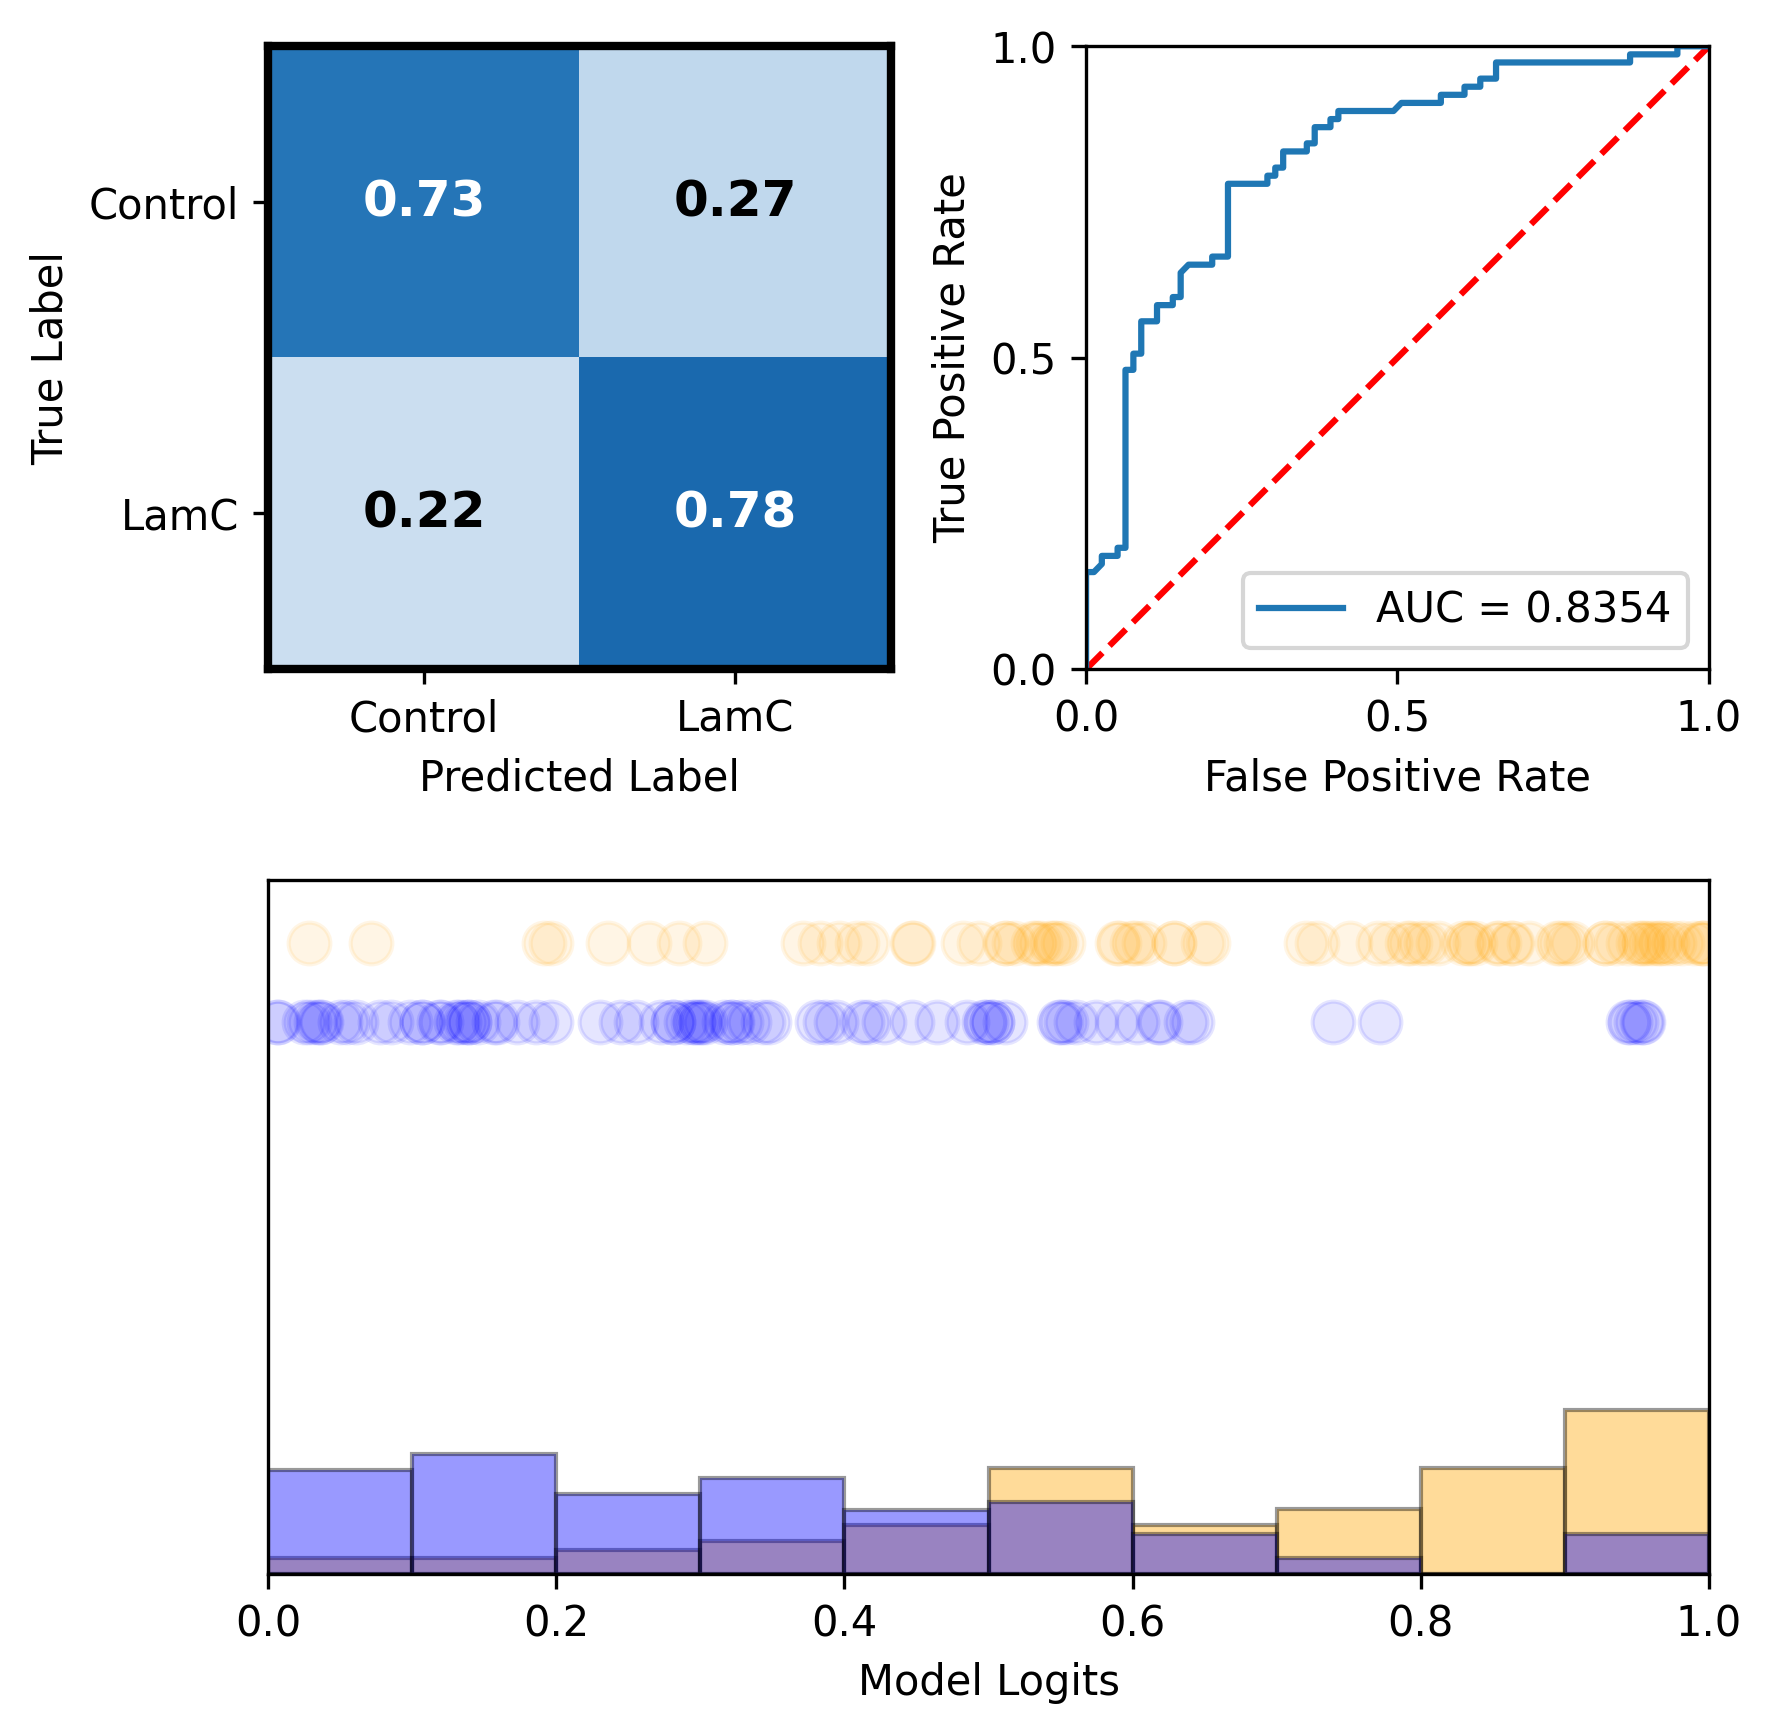


Saved: ./results_lamc_video/figures/Kfold_CMROCDist_LamC.png


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score

# === Step 0: Load R3D-18 and MC3-18 fold predictions ===
r3d_data = pd.read_csv("./results_lamc_video/kfold_data_lamc_video.csv")
mc3_data = pd.read_csv("./results_lamc_video_comparison/mc3_18/kfold_data_mc3_18.csv")

# === Step 1: Per-fold ensemble stats ===
fold_accs = []
fold_aucs = []
all_preds = []
all_labels = []

for fold in range(1, 6):
    r3d_p  = r3d_data[f"Raw Preds {fold}"].dropna().to_numpy()
    mc3_p  = mc3_data[f"Raw Preds {fold}"].dropna().to_numpy()
    labels_fold = r3d_data[f"Labels {fold}"].dropna().to_numpy()

    # Simple average ensemble
    ens_p = (r3d_p + mc3_p) / 2.0
    ens_binary = (ens_p >= 0.5).astype(int)

    acc = accuracy_score(labels_fold, ens_binary)
    fpr_f, tpr_f, _ = roc_curve(labels_fold, ens_p)
    auc_f = auc(fpr_f, tpr_f)

    fold_accs.append(acc)
    fold_aucs.append(auc_f)

    all_preds.extend(ens_p)
    all_labels.extend(labels_fold)

print(f" Fold Accuracies: {fold_accs}")
print(f" Average Accuracy: {np.mean(fold_accs)}")
print(f" Fold AUCs: {fold_aucs}")
print(f" Average AUC: {np.mean(fold_aucs)}")

# === Step 2: Aggregate (pooled) predictions and labels from all folds ===
preds = np.array(all_preds)
labels = np.array(all_labels)
binaryPred = (preds >= 0.5).astype(int)

overall_acc_mean_of_folds = np.mean(fold_accs)
overall_acc_pooled        = accuracy_score(labels, binaryPred)
fpr, tpr, _ = roc_curve(labels, preds)
overall_auc_pooled = auc(fpr, tpr)

print(f" Overall Test Accuracy (mean of folds): {overall_acc_mean_of_folds}")
print(f" Overall Test ROC AUC (from stacked preds): {overall_auc_pooled}")

# === Setup Plot ===
fig = plt.figure(figsize=(6, 6), dpi=300)
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

# === Confusion Matrix — manual imshow, guaranteed text visibility ===
cm = confusion_matrix(labels, binaryPred, labels=[0, 1]).astype(float)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

ax1.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1, aspect='equal')
ax1.set_xticks([0, 1]); ax1.set_xticklabels(["Control", "LamC"])
ax1.set_yticks([0, 1]); ax1.set_yticklabels(["Control", "LamC"])
ax1.set_xlabel("Predicted Label")
ax1.set_ylabel("True Label")

for i in range(2):
    for j in range(2):
        val = cm_norm[i, j]
        color = 'white' if val > 0.5 else 'black'
        ax1.text(j, i, f'{val:.2f}', ha='center', va='center',
                  fontsize=12, fontweight='bold', color=color)

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)

# === ROC Curve ===
ax2.plot([0, 1], [0, 1], 'r--')
ax2.plot(fpr, tpr, label=f"AUC = {np.mean(fold_aucs):.4f}")
ax2.set_aspect('equal')
ax2.set_ylim(0, 1)
ax2.set_xlim(0, 1)
ax2.set_yticks([0, 0.5, 1])
ax2.set_xticks([0, 0.5, 1])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(loc="lower right")

# === Logit Distribution ===
h = 10
bins = np.linspace(0, 1, 11)

ax3.scatter(preds[labels == 1], h * np.ones_like(preds[labels == 1]),
            c='orange', alpha=0.1, s=100, label="LamC")
ax3.scatter(preds[labels == 0], h * 0.875 * np.ones_like(preds[labels == 0]),
            c='blue', alpha=0.1, s=100, label="Control")

ax3.hist(preds[labels == 1], color='orange', alpha=0.4, bins=bins,
         density=True, edgecolor="black")
ax3.hist(preds[labels == 0], color='blue', alpha=0.4, bins=bins,
         density=True, edgecolor="black")

ax3.set_xlabel("Model Logits")
ax3.set_yticks([])
ax3.set_ylim(0, 1.1 * h)
ax3.set_xlim(0, 1)

# === Save ===
os.makedirs("./results_lamc_video/figures", exist_ok=True)
plt.tight_layout()
plt.savefig("./results_lamc_video/figures/Kfold_CMROCDist_LamC.png", dpi=300)
plt.show()

print(f"\nSaved: ./results_lamc_video/figures/Kfold_CMROCDist_LamC.png")

# Hand & OGDH Data Generation

In [ ]:
import cv2
import numpy as np
import os
import glob
from tqdm import tqdm

base_path = "/home/kondapav/Desktop/Drosophila_MelkaniLab/GIRISH/Dilated Cardiomyopathy Model"
resize = (512, 256)  # (W, H)
clipLen = 96


In [ ]:
avi_files = glob.glob(base_path + "/**/*.avi", recursive=True)
avi_files = sorted(avi_files)

X_frames = []
Y = []
paths = []

for path in tqdm(avi_files, desc="Processing videos"):
    cap = cv2.VideoCapture(path)
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, resize)
        frames.append(gray.astype(np.float32))
    cap.release()

    frames = np.stack(frames, axis=0) / 255.0
    if len(frames) < clipLen:
        pad = np.zeros((clipLen - len(frames), *resize), dtype=np.float32)
        frames = np.concatenate([frames, pad], axis=0)
    elif len(frames) > clipLen:
        idxs = np.linspace(0, len(frames) - 1, clipLen, dtype=int)
        frames = frames[idxs]

    frames = frames[:, None, :, :]            # (T, 1, H, W)
    frames = np.transpose(frames, (1, 0, 2, 3))  # (1, T, H, W)

    X_frames.append(frames)
    Y.append(0 if "Control hearts" in path else 1)  # 0 = HAND (control), 1 = HOGDH (mutant)
    paths.append(path)

In [ ]:
X_frames = np.stack(X_frames)  # (N, 1, 96, 256, 512)
Y = np.array(Y)
paths = np.array(paths)

np.save("X_frames_3dcnn_hand&Ogdh.npy", X_frames)
np.save("Y_labels_3dcnn_hand&Ogdh.npy", Y)
np.save("file_paths_3dcnn_hand&Ogdh.npy", paths)

print(" Saved shapes:")
print("X_frames:", X_frames.shape)
print("Y:", Y.shape)


# Hand & OGDH model experimentation

In [3]:
!pip install --upgrade sympy typing_extensions


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 46.7 MB/s  0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.1
    Uninstalling sympy-1.13.1:
      Successfully uninstalled sympy-1.13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0 requires sympy==1.13.1; python_version >= "3.9", but you have sympy 1.14.0 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [ ]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models.video import r3d_18, R3D_18_Weights

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, roc_curve


clipLen = 96
H, W = 128, 128
BATCH_SIZE = 2
EPOCHS = 30
VAL_SIZE = 0.25             
LR = 1e-4
WEIGHT_DECAY = 1e-5
PATIENCE = 6
NUM_WORKERS = 2
SEED = 42
USE_TTA = False              
THRESH_SELECT = "acc"        
KIN_MEAN = 0.401092
KIN_STD  = 0.22215633333333332

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

In [ ]:

def choose_threshold(y_true, y_prob, how="acc"):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_prob = np.asarray(y_prob).astype(float).ravel()
    if np.unique(y_true).size < 2 or y_prob.size == 0:
        return 0.5 
    if how == "acc":
        grid = np.linspace(0.05, 0.95, 181)
        scores = [accuracy_score(y_true, (y_prob > t).astype(int)) for t in grid]
        return float(grid[int(np.argmax(scores))])

    if how == "f1":
        grid = np.linspace(0.05, 0.95, 181)
        scores = [f1_score(y_true, (y_prob > t).astype(int)) for t in grid]
        return float(grid[int(np.argmax(scores))])

    fpr, tpr, thr = roc_curve(y_true, y_prob)
    j = tpr - fpr
    return float(thr[int(np.argmax(j))])

class VideoDataset(Dataset):
    def __init__(self, frames, labels, normalize=True):
        x = frames.astype(np.float32)  # (N, 1, T, H, W)
        if normalize:
            # scale to [0,1] if needed
            if np.nanmax(x) > 1.5:
                x = x / 255.0
            # single-channel kinetics normalization
            x = (x - KIN_MEAN) / KIN_STD
        self.frames = torch.tensor(x, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.frames[idx], self.labels[idx]

def make_loader(X_sub, y_sub, shuffle, bs=BATCH_SIZE, normalize=True):
    ds = VideoDataset(X_sub, y_sub, normalize=normalize)
    return DataLoader(ds, batch_size=bs, shuffle=shuffle, num_workers=NUM_WORKERS,
                      pin_memory=(device.type == "cuda"))

class ResNet3DClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = r3d_18(weights=R3D_18_Weights.KINETICS400_V1)
        old = self.backbone.stem[0]  # Conv3d(3,64,(3,7,7),(1,2,2),(1,3,3))
        new = nn.Conv3d(1, old.out_channels, kernel_size=old.kernel_size,
                        stride=old.stride, padding=old.padding, bias=False)
        with torch.no_grad():
            if old.weight.shape[1] == 3:
                w = old.weight.mean(dim=1, keepdim=True)  # -> (64,1,3,7,7)
                new.weight.copy_(w)
            else:
                nn.init.kaiming_normal_(new.weight, mode='fan_out', nonlinearity='relu')
        self.backbone.stem[0] = new
        self.backbone.fc = nn.Linear(512, 1)  # logits

    def forward(self, x):
        return self.backbone(x).squeeze(-1)  # (B,)

def evaluate(model, loader, criterion=None, tta=False):
    model.eval()
    losses, all_logits, all_labels = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            logits = model(xb)
            if tta:
                xb_flip = torch.flip(xb, dims=[-1]) 
                logits = 0.5 * (logits + model(xb_flip))

            if criterion is not None:
                loss = criterion(logits, yb)
                losses.append(loss.item())

            all_logits.append(logits.detach().cpu())
            all_labels.append(yb.detach().cpu())

    if all_logits:
        logits = torch.cat(all_logits).numpy()
        labels = torch.cat(all_labels).numpy()
    else:
        logits = np.array([]); labels = np.array([])

    probs = 1.0 / (1.0 + np.exp(-logits)) if logits.size else np.array([])
    auc = np.nan
    if labels.size and np.unique(labels).size == 2:
        try:
            auc = roc_auc_score(labels, probs)
        except ValueError:
            auc = np.nan
    loss_mean = float(np.mean(losses)) if losses else np.nan
    return loss_mean, auc, probs, labels


In [18]:


X = np.load("X_frames_3dcnn_hand&Ogdh.npy")  
Y = np.load("Y_labels_3dcnn_hand&Ogdh.npy") 
print("Shapes:", X.shape, Y.shape)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = []
preds_all_folds, labels_all_folds, fold_sizes, chosen_thresholds = [], [], [], []

for fold, (train_idx, test_idx) in enumerate(kf.split(X, Y), 1):
    print(f"\n Fold {fold}")

    X_trfull, y_trfull = X[train_idx], Y[train_idx]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=SEED)
    tr_sub_idx, val_sub_idx = next(sss.split(X_trfull, y_trfull))
    X_tr, y_tr = X_trfull[tr_sub_idx], y_trfull[tr_sub_idx]
    X_val, y_val = X_trfull[val_sub_idx], y_trfull[val_sub_idx]
    X_te, y_te = X[test_idx], Y[test_idx]

    pos = float((y_tr == 1).sum()); neg = float((y_tr == 0).sum())
    pos_weight_value = (neg / max(pos, 1.0)) if pos > 0 else 1.0
    pos_weight = torch.tensor(pos_weight_value, device=device)

    train_loader = make_loader(X_tr, y_tr, shuffle=True,  bs=BATCH_SIZE, normalize=True)
    val_loader   = make_loader(X_val, y_val, shuffle=False, bs=1, normalize=True)
    test_loader  = make_loader(X_te, y_te, shuffle=False, bs=1, normalize=True)

    model = ResNet3DClassifier().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_state = None
    best_val_auc = -np.inf
    patience_ctr = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        for xb, yb in tqdm(train_loader, desc=f"Fold {fold} Epoch {epoch}", leave=False):
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            running_loss += loss.item()

        # Validate on VAL (not test)
        val_loss, val_auc, _, _ = evaluate(model, val_loader, criterion, tta=USE_TTA)
        scheduler.step(val_loss if not np.isnan(val_loss) else 0.0)

        print(f"Epoch {epoch:02d} - train_loss: {running_loss:.4f} | "
              f"val_loss: {val_loss:.4f} | val_auc: {val_auc:.4f}")

        improved = (val_auc > best_val_auc) if not np.isnan(val_auc) else False
        if improved:
            best_val_auc = val_auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(" Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    _, _, val_probs, val_labels = evaluate(model, val_loader, criterion=None, tta=USE_TTA)
    best_thr = choose_threshold(val_labels, val_probs, how=THRESH_SELECT)
    chosen_thresholds.append(best_thr)

    _, test_auc, test_probs, test_labels = evaluate(model, test_loader, criterion=None, tta=USE_TTA)
    test_preds_bin = (test_probs > best_thr).astype(int)
    test_acc = accuracy_score(test_labels, test_preds_bin)

    print(f" Fold {fold} - Test Accuracy: {test_acc:.4f} | Test AUC: {test_auc:.4f} | Thr={best_thr:.3f}")

    results.append((test_acc, test_auc))
    preds_all_folds.append(test_probs)
    labels_all_folds.append(test_labels.astype(int))
    fold_sizes.append(len(test_labels))


epoch = EPOCHS
df_stats = pd.DataFrame([
    {"Fold": i+1, "Num Testing": fold_sizes[i],
     "Test Accuracy": results[i][0], "Test AUC": results[i][1], "Threshold": chosen_thresholds[i]}
    for i in range(len(results))
])
df_stats.to_csv(f"kfold_stats_{epoch}ep.csv", index=False)

df_data = pd.DataFrame()
for i in range(len(preds_all_folds)):
    df_data[f"Raw Preds {i+1}"] = pd.Series(preds_all_folds[i])
    df_data[f"Labels {i+1}"]    = pd.Series(labels_all_folds[i])
df_data.to_csv(f"kfold_data_{epoch}ep.csv", index=False)

print(f"\n Saved: kfold_stats_{epoch}ep.csv and kfold_data_{epoch}ep.csv")


avg_acc = float(np.nanmean([r[0] for r in results]))
avg_auc = float(np.nanmean([r[1] for r in results]))
print(f"\n Average Accuracy: {avg_acc:.4f} | Average AUC: {avg_auc:.4f}")


Device: cuda
Shapes: (65, 1, 96, 256, 512) (65,)

🌀 Fold 1


Epoch 01 - train_loss: 14.7140 | val_loss: 0.3396 | val_auc: 0.9524


Epoch 02 - train_loss: 11.0371 | val_loss: 0.2892 | val_auc: 0.9762


Epoch 03 - train_loss: 4.6684 | val_loss: 0.1253 | val_auc: 1.0000


Epoch 04 - train_loss: 11.0701 | val_loss: 0.5197 | val_auc: 0.9762


...

Epoch 03 - train_loss: 9.1451 | val_loss: 0.4729 | val_auc: 0.8571


Epoch 04 - train_loss: 7.0371 | val_loss: 0.0923 | val_auc: 1.0000


Epoch 05 - train_loss: 9.5999 | val_loss: 0.2851 | val_auc: 0.9762


Epoch 06 - train_loss: 11.2351 | val_loss: 0.2345 | val_auc: 1.0000


Epoch 07 - train_loss: 12.3395 | val_loss: 0.3857 | val_auc: 0.9762
⏹️ Early stopping.
✅ Fold 5 - Test Accuracy: 0.9231 | Test AUC: 1.0000 | Thr=0.880

✅ Saved: kfold_stats_30ep.csv and kfold_data_30ep.csv

📊 Average Accuracy: 0.9077 | Average AUC: 0.9810


In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models.video import mc3_18, MC3_18_Weights
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, roc_curve

# ── Hyperparameters (same as R3D-18 run) ───────────────────────
clipLen      = 96
BATCH_SIZE   = 2
EPOCHS       = 30
VAL_SIZE     = 0.25
LR           = 1e-4
WEIGHT_DECAY = 1e-5
PATIENCE     = 6
NUM_WORKERS  = 2
SEED         = 42
USE_TTA      = False
THRESH_SELECT = "fixed"

KIN_MEAN = 0.401092
KIN_STD  = 0.22215633333333332

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

os.makedirs("./results_ogdh_video_comparison/mc3_18", exist_ok=True)
save_dir = "./results_ogdh_video_comparison/mc3_18"

# ── Load raw grayscale frames (same as R3D-18) ─────────────────
X = np.load("X_frames_3dcnn_hand&Ogdh.npy")   # (65, 1, 96, 256, 512)
Y = np.load("Y_labels_3dcnn_hand&Ogdh.npy")
print(f"Shapes: X={X.shape}  Y={Y.shape}")
print(f"Hand: {(Y==0).sum()}  OGDH: {(Y==1).sum()}")

def choose_threshold(y_true, y_prob, how="fixed"):
    if how == "fixed":
        return 0.5
    return 0.5

class VideoDataset(Dataset):
    def __init__(self, frames, labels, normalize=True):
        x = frames.astype(np.float32)
        if normalize:
            if np.nanmax(x) > 1.5:
                x = x / 255.0
            x = (x - KIN_MEAN) / KIN_STD
        self.frames = torch.tensor(x, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.frames[idx], self.labels[idx]

def make_loader(X_sub, y_sub, shuffle, bs=BATCH_SIZE, normalize=True):
    ds = VideoDataset(X_sub, y_sub, normalize=normalize)
    return DataLoader(ds, batch_size=bs, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"))

class MC3Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = mc3_18(weights=MC3_18_Weights.KINETICS400_V1)
        old = self.backbone.stem[0]
        new = nn.Conv3d(1, old.out_channels, kernel_size=old.kernel_size,
                        stride=old.stride, padding=old.padding, bias=False)
        with torch.no_grad():
            if old.weight.shape[1] == 3:
                w = old.weight.mean(dim=1, keepdim=True)
                new.weight.copy_(w)
            else:
                nn.init.kaiming_normal_(new.weight, mode='fan_out', nonlinearity='relu')
        self.backbone.stem[0] = new
        self.backbone.fc = nn.Linear(512, 1)
    def forward(self, x):
        return self.backbone(x).squeeze(-1)

def evaluate(model, loader, criterion=None, tta=False):
    model.eval()
    losses, all_logits, all_labels = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            logits = model(xb)
            if tta:
                xb_flip = torch.flip(xb, dims=[-1])
                logits = 0.5 * (logits + model(xb_flip))
            if criterion is not None:
                losses.append(criterion(logits, yb).item())
            all_logits.append(logits.detach().cpu())
            all_labels.append(yb.detach().cpu())
    logits = torch.cat(all_logits).numpy() if all_logits else np.array([])
    labels = torch.cat(all_labels).numpy() if all_labels else np.array([])
    probs  = 1.0/(1.0+np.exp(-logits)) if logits.size else np.array([])
    auc = np.nan
    if labels.size and np.unique(labels).size == 2:
        try: auc = roc_auc_score(labels, probs)
        except ValueError: pass
    loss_mean = float(np.mean(losses)) if losses else np.nan
    return loss_mean, auc, probs, labels

# ── Training loop ───────────────────────────────────────────────
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = []
preds_all_folds, labels_all_folds, fold_sizes, chosen_thresholds = [], [], [], []

for fold, (train_idx, test_idx) in enumerate(kf.split(X, Y), 1):
    print(f"\n🌀 Fold {fold}")

    X_trfull, y_trfull = X[train_idx], Y[train_idx]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=SEED)
    tr_sub_idx, val_sub_idx = next(sss.split(X_trfull, y_trfull))
    X_tr, y_tr   = X_trfull[tr_sub_idx], y_trfull[tr_sub_idx]
    X_val, y_val = X_trfull[val_sub_idx], y_trfull[val_sub_idx]
    X_te, y_te   = X[test_idx], Y[test_idx]

    pos = float((y_tr == 1).sum()); neg = float((y_tr == 0).sum())
    pos_weight_value = (neg / max(pos, 1.0)) if pos > 0 else 1.0
    pos_weight = torch.tensor(pos_weight_value, device=device)

    train_loader = make_loader(X_tr, y_tr, shuffle=True, bs=BATCH_SIZE, normalize=True)
    val_loader   = make_loader(X_val, y_val, shuffle=False, bs=1, normalize=True)
    test_loader  = make_loader(X_te, y_te, shuffle=False, bs=1, normalize=True)

    model = MC3Classifier().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_state, best_val_auc, patience_ctr = None, -np.inf, 0

    for epoch in range(1, EPOCHS+1):
        model.train()
        running_loss = 0.0
        for xb, yb in tqdm(train_loader, desc=f"Fold {fold} Ep {epoch}", leave=False):
            xb = xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)
            logits = model(xb); loss = criterion(logits, yb)
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step(); running_loss += loss.item()

        val_loss, val_auc, _, _ = evaluate(model, val_loader, criterion, tta=USE_TTA)
        scheduler.step(val_loss if not np.isnan(val_loss) else 0.0)
        print(f"Epoch {epoch:02d} - train_loss: {running_loss:.4f} | val_loss: {val_loss:.4f} | val_auc: {val_auc:.4f}")

        improved = (val_auc > best_val_auc) if not np.isnan(val_auc) else False
        if improved:
            best_val_auc = val_auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
            torch.save(best_state, f"{save_dir}/best_model_fold{fold}.pt")
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(" Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    _, _, val_probs, val_labels = evaluate(model, val_loader, criterion=None, tta=USE_TTA)
    best_thr = choose_threshold(val_labels, val_probs, how=THRESH_SELECT)
    chosen_thresholds.append(best_thr)

    _, test_auc, test_probs, test_labels = evaluate(model, test_loader, criterion=None, tta=USE_TTA)
    test_preds_bin = (test_probs > best_thr).astype(int)
    test_acc = accuracy_score(test_labels, test_preds_bin)

    print(f" Fold {fold} - Test Accuracy: {test_acc:.4f} | Test AUC: {test_auc:.4f} | Thr={best_thr:.3f}")

    results.append((test_acc, test_auc))
    preds_all_folds.append(test_probs)
    labels_all_folds.append(test_labels.astype(int))
    fold_sizes.append(len(test_labels))
    del model; torch.cuda.empty_cache()

# ── Save results ────────────────────────────────────────────────
df_stats = pd.DataFrame([
    {"Fold": i+1, "Num Testing": fold_sizes[i],
     "Test Accuracy": results[i][0], "Test AUC": results[i][1], "Threshold": chosen_thresholds[i]}
    for i in range(len(results))
])
mean_row = {"Fold":"Mean","Num Testing":"",
            "Test Accuracy":df_stats["Test Accuracy"].mean(),
            "Test AUC":df_stats["Test AUC"].mean(),"Threshold":""}
std_row  = {"Fold":"Std","Num Testing":"",
            "Test Accuracy":df_stats["Test Accuracy"].std(),
            "Test AUC":df_stats["Test AUC"].std(),"Threshold":""}
df_stats = pd.concat([df_stats, pd.DataFrame([mean_row]), pd.DataFrame([std_row])], ignore_index=True)
df_stats.to_csv(f"{save_dir}/kfold_stats_mc3_18.csv", index=False)

df_data = pd.DataFrame()
for i in range(len(preds_all_folds)):
    df_data[f"Raw Preds {i+1}"] = pd.Series(preds_all_folds[i])
    df_data[f"Labels {i+1}"]    = pd.Series(labels_all_folds[i])
df_data.to_csv(f"{save_dir}/kfold_data_mc3_18.csv", index=False)

avg_acc = float(np.nanmean([r[0] for r in results]))
avg_auc = float(np.nanmean([r[1] for r in results]))
print(f"\n📊 MC3-18 OGDH Average Accuracy: {avg_acc:.4f} | Average AUC: {avg_auc:.4f}")
print(f"Saved: {save_dir}/kfold_stats_mc3_18.csv")

Device: cuda
Shapes: X=(65, 1, 96, 256, 512)  Y=(65,)
Hand: 35  OGDH: 30

🌀 Fold 1


Epoch 01 - train_loss: 11.9075 | val_loss: 1.4790 | val_auc: 1.0000


Epoch 02 - train_loss: 10.1713 | val_loss: 0.7542 | val_auc: 0.9762


Epoch 03 - train_loss: 10.4548 | val_loss: 0.1823 | val_auc: 1.0000


Epoch 04 - train_loss: 12.8575 | val_loss: 0.2678 | val_auc: 0.9762


...

Epoch 05 - train_loss: 11.6150 | val_loss: 0.4383 | val_auc: 0.8810


Epoch 06 - train_loss: 11.1344 | val_loss: 0.1971 | val_auc: 1.0000


Epoch 07 - train_loss: 7.6228 | val_loss: 0.1940 | val_auc: 1.0000


Epoch 08 - train_loss: 5.4421 | val_loss: 0.2019 | val_auc: 1.0000


Epoch 09 - train_loss: 7.7385 | val_loss: 0.1130 | val_auc: 1.0000
 Early stopping.
 Fold 5 - Test Accuracy: 0.9231 | Test AUC: 1.0000 | Thr=0.500

📊 MC3-18 OGDH Average Accuracy: 0.7846 | Average AUC: 0.9762
Saved: ./results_ogdh_video_comparison/mc3_18/kfold_stats_mc3_18.csv


In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.metrics import auc as sk_auc

# ── Load saved raw predictions from both models ────────────────
r3d_data = pd.read_csv("kfold_data_30ep.csv")  # R3D-18 OGDH (raw frames)
mc3_data = pd.read_csv("./results_ogdh_video_comparison/mc3_18/kfold_data_mc3_18.csv")

results = []
for fold in range(1, 6):
    r3d_p  = r3d_data[f"Raw Preds {fold}"].dropna().values
    mc3_p  = mc3_data[f"Raw Preds {fold}"].dropna().values
    labels = r3d_data[f"Labels {fold}"].dropna().values.astype(int)

    # Simple average ensemble
    ens_p = (r3d_p + mc3_p) / 2.0

    acc = accuracy_score(labels, (ens_p >= 0.5).astype(int))
    auc_v = roc_auc_score(labels, ens_p)

    print(f"Fold {fold}: R3D Acc={accuracy_score(labels,(r3d_p>=0.5).astype(int)):.4f} "
          f"AUC={roc_auc_score(labels,r3d_p):.4f} | "
          f"MC3 Acc={accuracy_score(labels,(mc3_p>=0.5).astype(int)):.4f} "
          f"AUC={roc_auc_score(labels,mc3_p):.4f} | "
          f"Ensemble Acc={acc:.4f} AUC={auc_v:.4f}")
    results.append((acc, auc_v))

avg_acc = np.mean([r[0] for r in results])
avg_auc = np.mean([r[1] for r in results])
std_acc = np.std([r[0] for r in results])
std_auc = np.std([r[1] for r in results])

print(f"\n{'='*55}")
print(f"OGDH VIDEO ENSEMBLE (R3D-18 + MC3-18) — FINAL")
print(f"{'='*55}")
print(f"Mean Acc   = {avg_acc:.4f} +/- {std_acc:.4f}")
print(f"Mean AUROC = {avg_auc:.4f} +/- {std_auc:.4f}")

# ── Bootstrap CI ─────────────────────────────────────────────
all_probs, all_labels = [], []
for fold in range(1, 6):
    r3d_p  = r3d_data[f"Raw Preds {fold}"].dropna().values
    mc3_p  = mc3_data[f"Raw Preds {fold}"].dropna().values
    labels = r3d_data[f"Labels {fold}"].dropna().values.astype(int)
    all_probs.extend((r3d_p + mc3_p) / 2.0)
    all_labels.extend(labels)

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

rng = np.random.default_rng(42)
b_accs, b_aucs = [], []
for _ in range(1000):
    idx = rng.integers(0, len(all_labels), len(all_labels))
    if np.unique(all_labels[idx]).size < 2: continue
    b_accs.append(accuracy_score(all_labels[idx], (all_probs[idx]>=0.5).astype(int)))
    f,t,_ = roc_curve(all_labels[idx], all_probs[idx])
    b_aucs.append(sk_auc(f,t))

print(f"95%CI Acc   [{np.percentile(b_accs,2.5)*100:.2f}%, {np.percentile(b_accs,97.5)*100:.2f}%]")
print(f"95%CI AUROC [{np.percentile(b_aucs,2.5):.4f}, {np.percentile(b_aucs,97.5):.4f}]")

# ── Permutation test ───────────────────────────────────────────
obs_auc = roc_auc_score(all_labels, all_probs)
perm_aucs = []
for _ in range(1000):
    shuffled = rng.permutation(all_labels)
    perm_aucs.append(roc_auc_score(shuffled, all_probs))
p_value = np.mean(np.array(perm_aucs) >= obs_auc)

print(f"\nPermutation test: observed AUC={obs_auc:.4f}, "
      f"permuted mean={np.mean(perm_aucs):.4f}+/-{np.std(perm_aucs):.4f}, p={p_value:.4f}")

print(f"\nvs single R3D-18: Acc=90.77%  AUC=0.9810")

Fold 1: R3D Acc=1.0000 AUC=1.0000 | MC3 Acc=0.5385 AUC=1.0000 | Ensemble Acc=0.7692 AUC=1.0000
Fold 2: R3D Acc=0.9231 AUC=1.0000 | MC3 Acc=0.9231 AUC=1.0000 | Ensemble Acc=1.0000 AUC=1.0000
Fold 3: R3D Acc=0.8462 AUC=0.9524 | MC3 Acc=0.6154 AUC=0.8810 | Ensemble Acc=0.7692 AUC=0.9762
Fold 4: R3D Acc=0.7692 AUC=1.0000 | MC3 Acc=0.9231 AUC=1.0000 | Ensemble Acc=0.8462 AUC=1.0000
Fold 5: R3D Acc=0.6923 AUC=1.0000 | MC3 Acc=0.9231 AUC=1.0000 | Ensemble Acc=1.0000 AUC=1.0000

OGDH VIDEO ENSEMBLE (R3D-18 + MC3-18) — FINAL
Mean Acc   = 0.8769 +/- 0.1043
Mean AUROC = 0.9952 +/- 0.0095
95%CI Acc   [78.46%, 95.38%]
95%CI AUROC [0.9295, 1.0000]

Permutation test: observed AUC=0.9733, permuted mean=0.4950+/-0.0735, p=0.0000

vs single R3D-18: Acc=90.77%  AUC=0.9810


#### Test Results

Per-fold thresholds: [0.4349999999999999, 0.4249999999999999, 0.95, 0.595, 0.8799999999999999]
Average Accuracy: 0.9076923076923077
Average AUC: 0.980952380952381
Pooled labels shape: (65,), Mutant count: 30, Control count: 35
Preds range: min=0.0024, max=0.9999
Mutant preds count: 30
Control preds count: 35


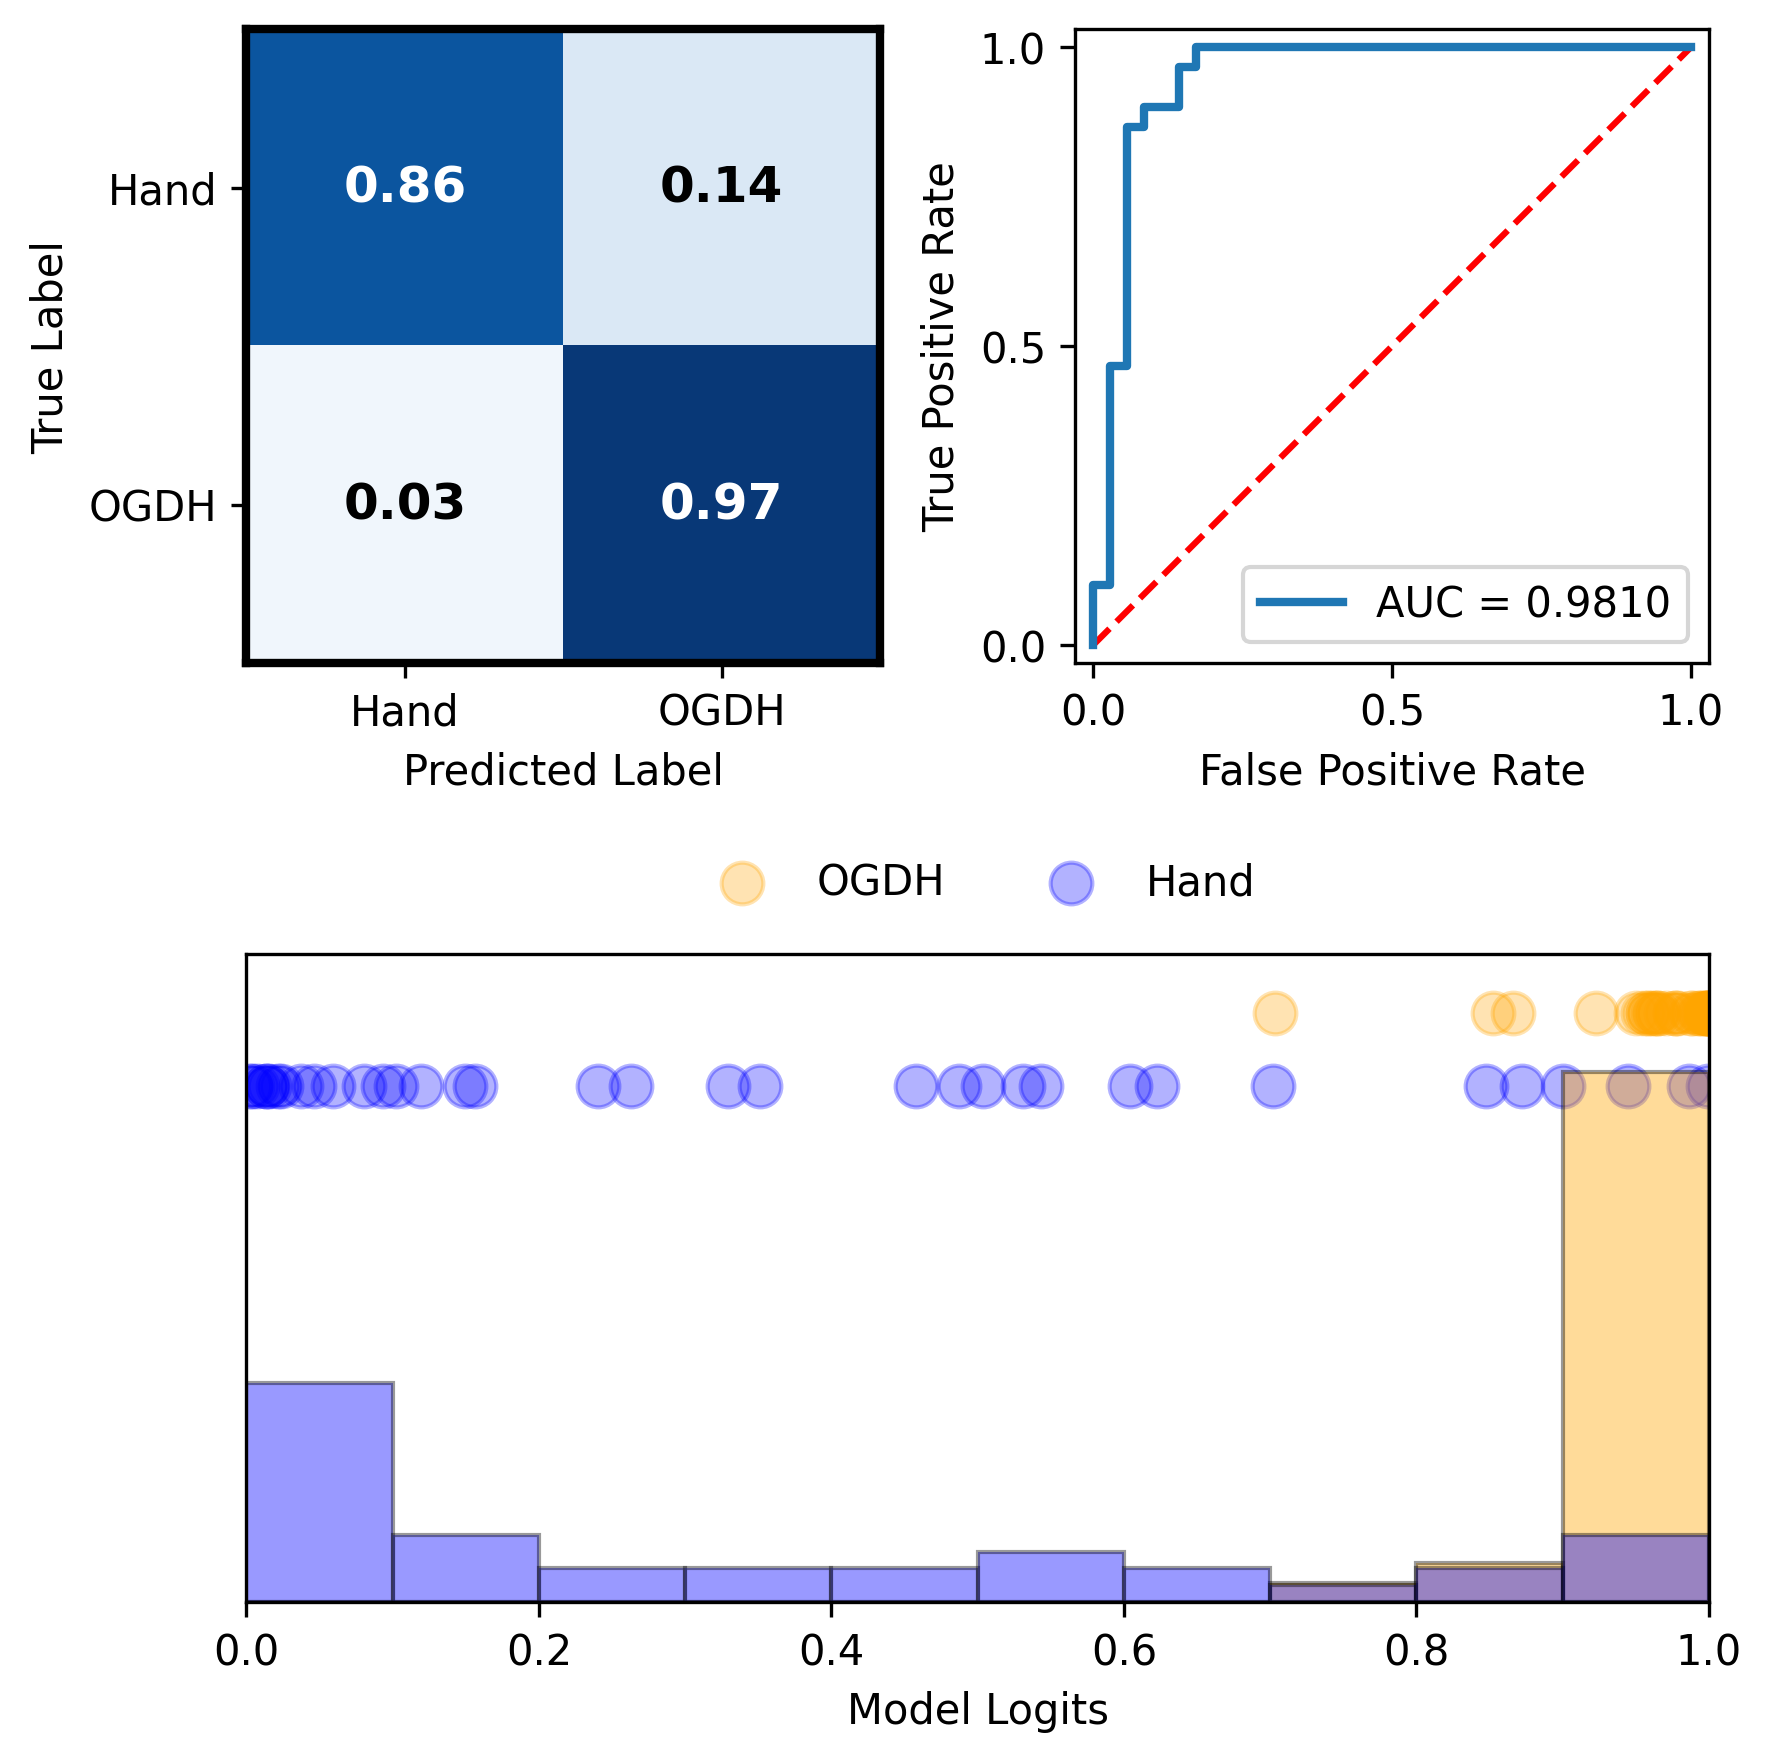

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score

# === Step 0: Load predictions AND per-fold thresholds ===
df_data = pd.read_csv("kfold_data_30ep.csv")
df_stats = pd.read_csv("kfold_stats_30ep.csv")
fold_thresholds = df_stats["Threshold"].tolist()
print(f"Per-fold thresholds: {fold_thresholds}")

# === Step 1: Per-fold stats using EACH FOLD'S OWN THRESHOLD ===
fold_accs, fold_aucs = [], []
all_preds, all_labels, all_binary = [], [], []

for fold in range(1, 6):
    preds_fold  = df_data[f"Raw Preds {fold}"].dropna().to_numpy()
    labels_fold = df_data[f"Labels {fold}"].dropna().to_numpy()

    thr = fold_thresholds[fold - 1]
    binary_fold = (preds_fold > thr).astype(int)

    acc = accuracy_score(labels_fold, binary_fold)
    fpr_f, tpr_f, _ = roc_curve(labels_fold, preds_fold)
    auc_f = auc(fpr_f, tpr_f)

    fold_accs.append(acc)
    fold_aucs.append(auc_f)
    all_preds.extend(preds_fold)
    all_labels.extend(labels_fold)
    all_binary.extend(binary_fold)

print(f"Average Accuracy: {np.mean(fold_accs)}")
print(f"Average AUC: {np.mean(fold_aucs)}")

preds = np.array(all_preds)
labels = np.array(all_labels)
binaryPred = np.array(all_binary)

fpr, tpr, _ = roc_curve(labels, preds)
overall_auc_pooled = auc(fpr, tpr)
print(f"Pooled labels shape: {labels.shape}, Mutant count: {(labels==1).sum()}, Control count: {(labels==0).sum()}")
print(f"Preds range: min={preds.min():.4f}, max={preds.max():.4f}")

# === Setup Plot ===
fig = plt.figure(figsize=(6, 6), dpi=300)
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

# === Confusion Matrix ===
cm = confusion_matrix(labels, binaryPred, labels=[0, 1]).astype(float)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

ax1.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1, aspect='equal')
ax1.set_xticks([0, 1]); ax1.set_xticklabels(["Hand", "OGDH"])
ax1.set_yticks([0, 1]); ax1.set_yticklabels(["Hand", "OGDH"])
ax1.set_xlabel("Predicted Label")
ax1.set_ylabel("True Label")

for i in range(2):
    for j in range(2):
        val = cm_norm[i, j]
        color = 'white' if val > 0.5 else 'black'
        ax1.text(j, i, f'{val:.2f}', ha='center', va='center',
                  fontsize=12, fontweight='bold', color=color)

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)

# === ROC Curve ===
ax2.plot([0, 1], [0, 1], 'r--')
ax2.plot(fpr, tpr, label=f"AUC = {np.mean(fold_aucs):.4f}", lw=2, zorder=5)
ax2.set_aspect('equal')

# Add small margin so curve doesn't hide behind the border
ax2.set_xlim(-0.03, 1.03)
ax2.set_ylim(-0.03, 1.03)
ax2.set_yticks([0, 0.5, 1])
ax2.set_xticks([0, 0.5, 1])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(loc="lower right")

# === Logit Distribution ===
h = 10
bins = np.linspace(0, 1, 11)

print(f"Mutant preds count: {len(preds[labels == 1])}")
print(f"Control preds count: {len(preds[labels == 0])}")

ax3.scatter(preds[labels == 1], h * np.ones_like(preds[labels == 1]),
            c='orange', alpha=0.3, s=100, label="OGDH")
ax3.scatter(preds[labels == 0], h * 0.875 * np.ones_like(preds[labels == 0]),
            c='blue', alpha=0.3, s=100, label="Hand")

ax3.hist(preds[labels == 1], color='orange', alpha=0.4, bins=bins,
         density=True, edgecolor="black")
ax3.hist(preds[labels == 0], color='blue', alpha=0.4, bins=bins,
         density=True, edgecolor="black")

ax3.set_xlabel("Model Logits")
ax3.set_yticks([])
ax3.set_ylim(0, 1.1 * h)
ax3.set_xlim(0, 1)
ax3.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2,
            frameon=False, fontsize=10)
# === Save ===
os.makedirs("./results_ogdh_video/figures", exist_ok=True)
plt.tight_layout()
plt.savefig("./results_ogdh_video/figures/Kfold_CMROCDist_Ogdh.png", dpi=300)
plt.show()